In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/resume_dataset.csv')

In [3]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [4]:
print(df.shape)
print(df.head())
print(df['Category'].value_counts())

(962, 2)
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Busi

In [5]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+', ' ', text)         
    text = re.sub(r'www\S+', ' ', text)          
    text = re.sub(r'@\S+', ' ', text)             
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)      
    text = re.sub(r'\s+', ' ', text)              
    text = text.lower()
    return text.strip()

In [6]:
df['cleaned_resume'] = df['Resume'].apply(clean_resume)

In [7]:
df[['Category', 'cleaned_resume']].head()

,Category,cleaned_resume
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may to may b e uit rgpv data...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


In [8]:
# LabelEncoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

In [9]:
print(df[['Category', 'Category_Encoded']].sample(10))

                      Category  Category_Encoded
525         Operations Manager                18
876                 Blockchain                 3
331             Java Developer                15
758                     Hadoop                13
578           Python Developer                20
656  Network Security Engineer                17
817              ETL Developer                10
615            DevOps Engineer                 8
653            DevOps Engineer                 8
586           Python Developer                20


In [10]:
# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category_Encoded']

In [11]:
print(X.shape)

(962, 5000)


In [12]:
# Train_Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy= accuracy_score(y_test,y_pred)

print('Accuracy',accuracy)

Accuracy 0.9948186528497409


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00         8
          17       1.00    

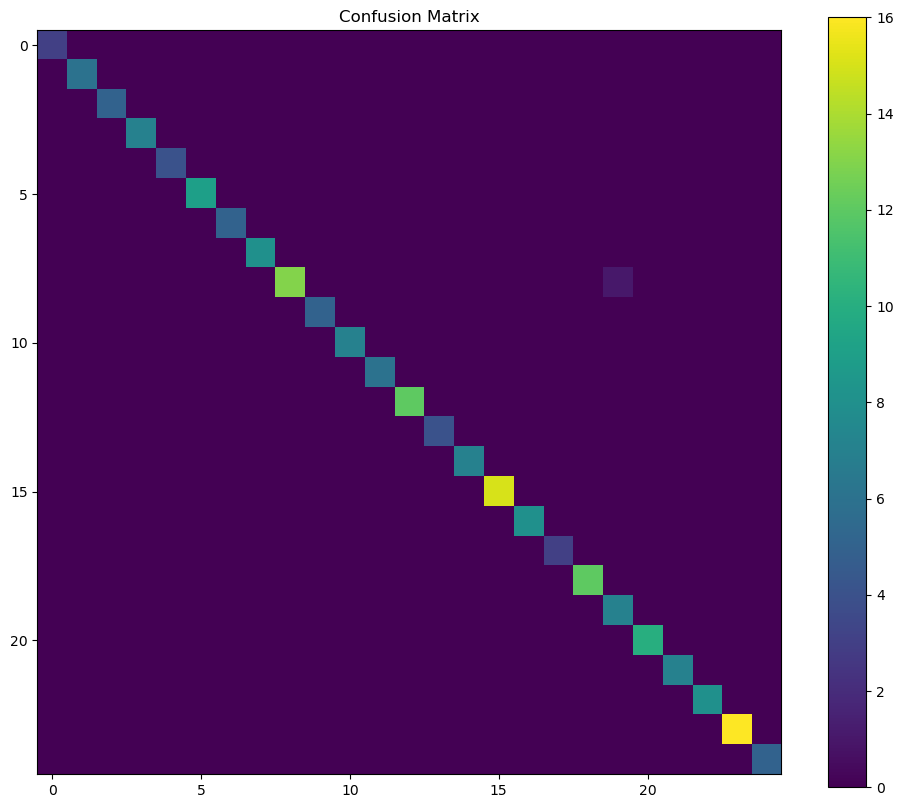

In [15]:
from sklearn.metrics import classification_report , confusion_matrix

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()

In [16]:
import joblib
joblib.dump(model,"../models/resume_classifier.pkl")
joblib.dump(tfidf,"../models/tfidf_vectorizer.pkl")
joblib.dump(le,"../models/label_encoder.pkl")

['../models/label_encoder.pkl']